In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("data.csv")

# First 10 rows
print("First 10 rows:")
print(df.head(10))

# Dataset structure
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


First 10 rows:
   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0
5        60    102       127     300.0
6        60    110       136     374.0
7        45    104       134     253.3
8        30    109       133     195.1
9        60     98       124     269.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  169 non-null    int64  
 1   Pulse     169 non-null    int64  
 2   Maxpulse  169 non-null    int64  
 3   Calories  164 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.4 KB
None

Summary Statistics:
         Duration       Pulse    Maxpulse     Calories
count  169.000000  169.000000  169.000000   164.000000
mean    63.846154

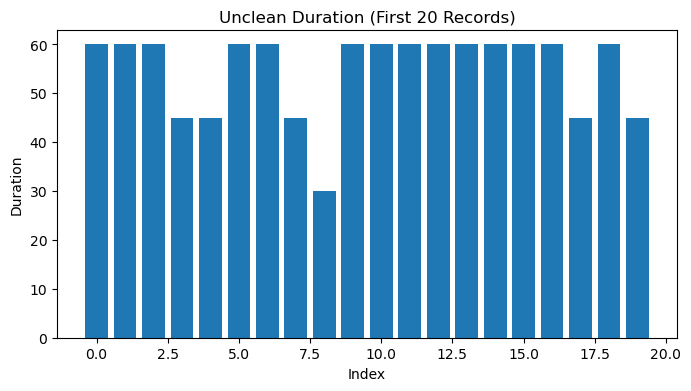

In [11]:
plt.figure(figsize=(8,4))
plt.bar(df.index[:20], df["Duration"][:20])
plt.title("Unclean Duration (First 20 Records)")
plt.xlabel("Index")
plt.ylabel("Duration")
plt.savefig("unclean_duration.png")
plt.show()

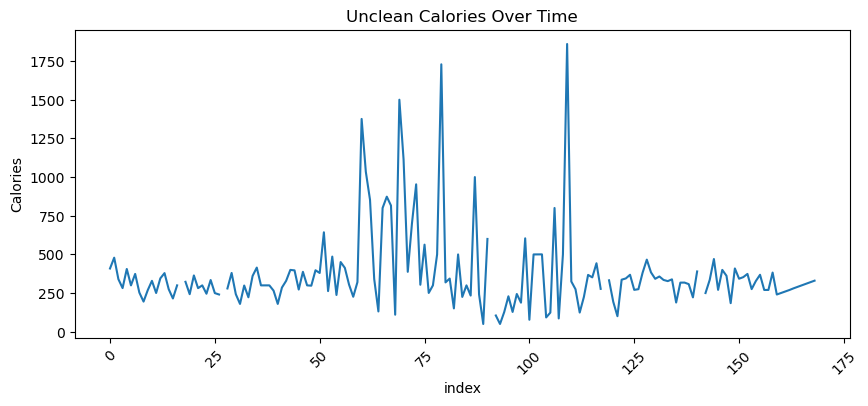

In [56]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df["Calories"])
plt.title("Unclean Calories Over Time")
plt.xlabel("index")
plt.ylabel("Calories")
plt.xticks(rotation= 45)
plt.show()

In [24]:
df['Calories'].fillna(df['Calories'].mean())

0      409.1
1      479.0
2      340.0
3      282.4
4      406.0
       ...  
164    290.8
165    300.0
166    310.2
167    320.4
168    330.4
Name: Calories, Length: 169, dtype: float64

In [29]:
median_duration = df["Duration"].median()
df.loc[df["Duration"] > 120, "Duration"] = median_duration
print(median_duration)

60.0


In [27]:
df.drop_duplicates(inplace=True)
print("\nCleaned Data (head):\n", df.head())


Cleaned Data (head):
    Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0


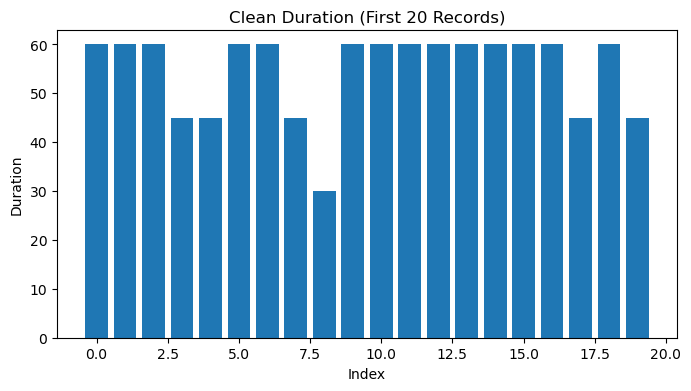

In [30]:
plt.figure(figsize=(8,4))
plt.bar(df.index[:20], df["Duration"][:20])
plt.title("Clean Duration (First 20 Records)")
plt.xlabel("Index")
plt.ylabel("Duration")
plt.savefig("clean_duration.png")
plt.show()

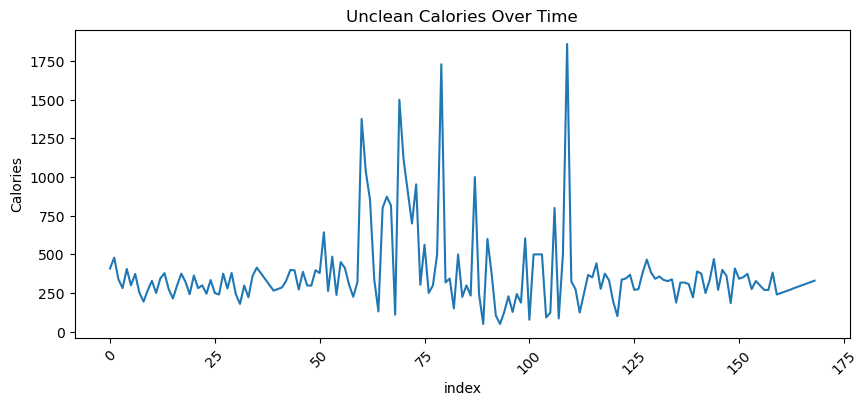

In [33]:
plt.figure(figsize=(10,4))
plt.plot(df.index, df["Calories"])
plt.title("Unclean Calories Over Time")
plt.xlabel("index")
plt.ylabel("Calories")
plt.xticks(rotation= 45)
plt.show()

In [32]:
titanic = pd.read_csv("Titanic-Dataset.csv")

In [34]:
drop_cols = ['alive', 'alone', 'embark_town', 'who', 'adult_male', 'deck', 'embarked', 'class']
titanic.drop(columns=drop_cols, inplace=True, errors="ignore")
print("\nTitanic Dataset (head):\n", titanic.head())


Titanic Dataset (head):
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   

In [36]:
le = LabelEncoder()
titanic["Sex"] = le.fit_transform(titanic["Sex"])

In [38]:
titanic[col].fillna(titanic[col].mean())


0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [39]:
titanic[col].fillna(titanic[col].mode()[0])

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [40]:
print("\nTitanic After Encoding & Filling Missing:\n", titanic.head())


Titanic After Encoding & Filling Missing:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare Cabin Embarked  
0         A/5 21171   7.2500   NaN        S  
1          PC 17599  71.2833   C85        C  
2  STON/O2. 3101282   7.9250   NaN        S  
3            113803  53.1000  C123        S  
4            373450   

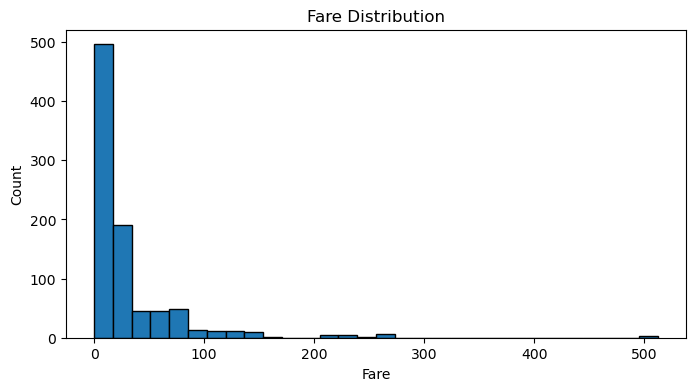

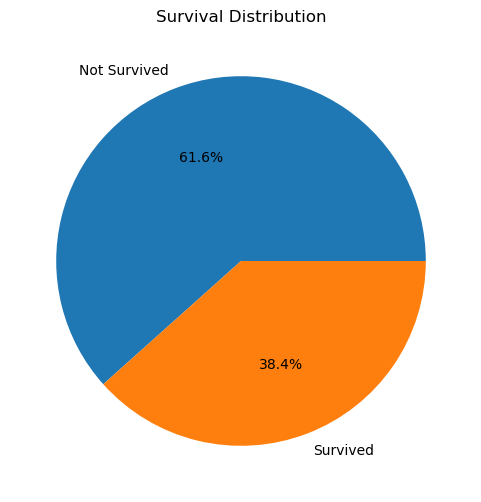

In [43]:
plt.figure(figsize=(8,4))
plt.hist(titanic["Fare"], bins=30, edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.savefig("titanic_fare_hist.png")
plt.show()

# Pie chart of survival
plt.figure(figsize=(6,6))
titanic["Survived"].value_counts().plot.pie(autopct="%1.1f%%", labels=["Not Survived","Survived"])
plt.title("Survival Distribution")
plt.ylabel("")
plt.savefig("titanic_survival_pie.png")
plt.show()


In [55]:
scaler = MinMaxScaler()
numerical_cols = ["Age", "Fare"]
titanic[numerical_cols] = scaler.fit_transform(titanic[numerical_cols])
print("After Normalizing score columns:")
print(titanic[numerical_cols].head())

After Normalizing score columns:
        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713


In [47]:
# Features and Target
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.25, random_state=42
)

print("\nTrain Shape:", X_train.shape, " Test Shape:", X_test.shape)


Train Shape: (668, 11)  Test Shape: (223, 11)
